## 🔤 Text Preprocessing Steps

Before vectorization, each SMS message is processed through the following pipeline:

| Step | Action | Description |
| :---: | :--- | :--- |
| **01** | 🔡 **Lowercasing** | Convert all text to lowercase to ensure uniformity. |
| **02** | ✂️ **Tokenization** | Split text into individual words (tokens). |
| **03** | 🧹 **Remove Special Characters** | Removing special character's like: (, ), [, ], +, - etc. |
| **04** | 🚫 **Remove Stopwords & Punctuation** | Eliminate common words (e.g., *the, is, and*) and punctuation marks that add no predictive value. |
| **05** | 🌱 **Stemming** | Reduce words to their root form (e.g., *"calling" → "call"*). |

In [8]:
from typing import List, Dict
import string
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [9]:
df = pd.read_csv("../data/cleaned/cleaned2.csv")
df.head()

,target,text,count_alphabet,count_words,count_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [20]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [27]:
def preprocessing(text: str):
  # converting text into lower case
  text = text.lower()

  # breaking text into tokens
  text = word_tokenize(text)

  # removing special character's
  ans = [word for word in text if word.isalnum()]

  # removing stopwords and punchation's from the text
  text = ans[:]
  ans.clear()

  ans = []
  for word in text:
    if word not in stopwords.words("english") and word not in string.punctuation:
      ans.append(word)

  # apply steaming on the text
  text = ans[:]
  ans.clear()

  ans = [ps.stem(word) for word in text]
  
  return " ".join(ans)

In [28]:
df["preprocessed_text"] = df["text"].apply(preprocessing)

In [29]:
df.head()

,target,text,count_alphabet,count_words,count_sent,preprocessed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


### most frequent word in both category after preprocessing

In [31]:
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [32]:
def plot_word_cloud(text: list, size: tuple = (10, 5)) -> None:
  wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white'
  ).generate_from_frequencies(Counter(text))

  plt.figure(figsize=size)
  plt.imshow(wordcloud, interpolation="bilinear")
  plt.axis("off")
  plt.show()

In [39]:
ham_text = " ".join(df[df["target"] == 0]["preprocessed_text"]).split(" ")
spam_text = " ".join(df[df["target"] == 1]["preprocessed_text"]).split(" ")
Counter(ham_text).most_common()

[('u', 883),
 ('go', 404),
 ('get', 349),
 ('gt', 288),
 ('lt', 287),
 ('2', 284),
 ('come', 275),
 ('got', 236),
 ('know', 236),
 ('like', 234),
 ('call', 233),
 ('time', 219),
 ('ok', 217),
 ('love', 216),
 ('good', 213),
 ('want', 208),
 ('ur', 197),
 ('day', 190),
 ('need', 171),
 ('one', 165),
 ('lor', 159),
 ('4', 155),
 ('home', 152),
 ('think', 149),
 ('see', 147),
 ('take', 143),
 ('still', 143),
 ('da', 142),
 ('tell', 133),
 ('make', 129),
 ('say', 127),
 ('back', 127),
 ('today', 123),
 ('hope', 122),
 ('ask', 121),
 ('sorri', 121),
 ('n', 120),
 ('send', 120),
 ('r', 120),
 ('work', 118),
 ('dont', 118),
 ('meet', 112),
 ('hi', 111),
 ('well', 109),
 ('thing', 109),
 ('wat', 108),
 ('k', 107),
 ('much', 107),
 ('night', 107),
 ('oh', 106),
 ('miss', 106),
 ('happi', 104),
 ('give', 102),
 ('later', 100),
 ('hey', 100),
 ('great', 97),
 ('na', 96),
 ('wait', 96),
 ('way', 95),
 ('alreadi', 90),
 ('thank', 87),
 ('let', 86),
 ('yeah', 86),
 ('text', 85),
 ('feel', 83),
 ('re

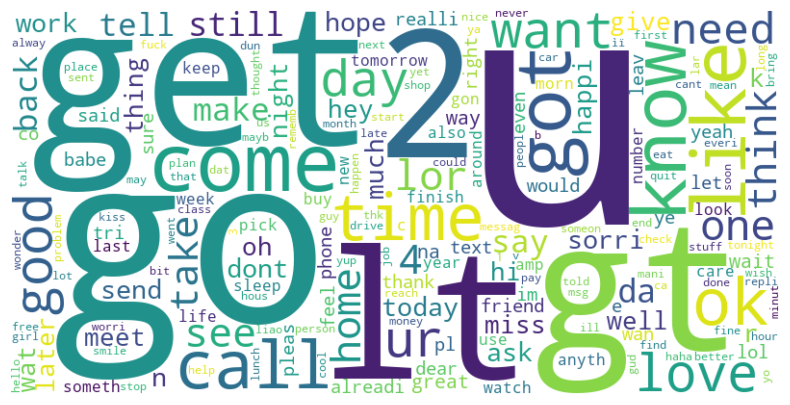

In [40]:
plot_word_cloud(text=ham_text)

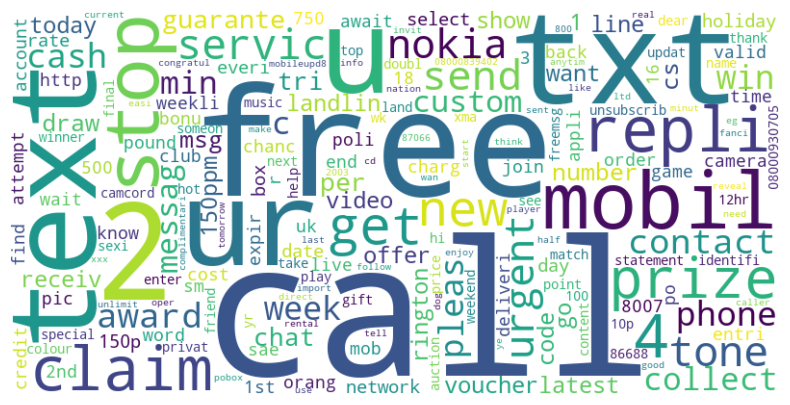

In [41]:
plot_word_cloud(spam_text)

In [42]:
df.to_csv("../data/cleaned/spam.csv", index= False)